# Online Sporting Goods Order Forecaster

## Project goal

This project builds a machine-learning workflow to forecast order quantity for an online sporting-goods / wholesale-retail dataset. The goal is to support inventory planning by estimating future demand by time period and product segment.

**Main prediction task used in this notebook:**  
Predict monthly `quantity_ordered` by product category / product group using historical order and product-supplier information.

**Evaluation metrics:** MAE, MSE, RMSE, and R².  
**Business interpretation:** lower RMSE means fewer order-quantity errors, which can reduce overstocking, stockouts, and inventory-related cost.

## Data

In [1]:
import pandas as pd
df_od_raw = pd.read_csv('orders.csv')
df_ps_raw = pd.read_csv('product-supplier.csv')

In [2]:
df_od_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185013 entries, 0 to 185012
Data columns (total 9 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Customer ID                        185013 non-null  int64  
 1   Customer Status                    185013 non-null  object 
 2   Date Order was placed              185013 non-null  object 
 3   Delivery Date                      185013 non-null  object 
 4   Order ID                           185013 non-null  int64  
 5   Product ID                         185013 non-null  int64  
 6   Quantity Ordered                   185013 non-null  int64  
 7   Total Retail Price for This Order  185013 non-null  float64
 8   Cost Price Per Unit                185013 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 12.7+ MB


In [3]:
df_od_raw.head(3)

,Customer ID,Customer Status,Date Order was placed,Delivery Date,Order ID,Product ID,Quantity Ordered,Total Retail Price for This Order,Cost Price Per Unit
0,579,Silver,01-Jan-17,07-Jan-17,123002578,220101400106,2,92.6,20.70
1,7574,SILVER,01-Jan-17,05-Jan-17,123004074,210201000009,1,21.7,9.95
2,28861,Gold,01-Jan-17,04-Jan-17,123000871,230100500068,1,1.7,0.80


In [4]:
df_ps_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5504 entries, 0 to 5503
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product ID        5504 non-null   int64 
 1   Product Line      5504 non-null   object
 2   Product Category  5504 non-null   object
 3   Product Group     5504 non-null   object
 4   Product Name      5504 non-null   object
 5   Supplier Country  5504 non-null   object
 6   Supplier Name     5504 non-null   object
 7   Supplier ID       5504 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 344.1+ KB


In [5]:
df_ps_raw.head(3)

,Product ID,Product Line,Product Category,Product Group,Product Name,Supplier Country,Supplier Name,Supplier ID
0,210100100001,Children,Children Outdoors,"Outdoor things, Kids",Boy's and Girl's Ski Pants with Braces,NO,Scandinavian Clothing A/S,50
1,210100100002,Children,Children Outdoors,"Outdoor things, Kids",Children's Jacket,ES,Luna sastreria S.A.,4742
2,210100100003,Children,Children Outdoors,"Outdoor things, Kids",Children's Jacket Sidney,NO,Scandinavian Clothing A/S,50


## Data Cleaning

In [6]:
# Copy
df_od = df_od_raw.copy()
df_ps = df_ps_raw.copy()

# rename all the columns to snake case
df_od.columns = df_od.columns.str.lower().str.replace(' ', '_')
print(df_od.columns)
df_ps.columns = df_ps.columns.str.lower().str.replace(' ', '_')
print(df_ps.columns)


# Replace customer status to upper cases
df_od['customer_status'] = df_od['customer_status'].str.upper()
# Add Item Retail Value features
df_od['item_retail_value'] = df_od['total_retail_price_for_this_order'] / df_od['quantity_ordered']
# Convert dates to datetime objects based on the format
df_od['date_order_was_placed'] = pd.to_datetime(
    df_od['date_order_was_placed'],
    format='%d-%b-%y'
)

df_od['delivery_date'] = pd.to_datetime(
    df_od['delivery_date'],
    format='%d-%b-%y'
)
# Subtract delivery date from order date
df_od['days_to_deliver'] = (df_od['delivery_date'] - df_od['date_order_was_placed']).dt.days

# Segment to year, month, and day
df_od['date_year'] = pd.to_datetime(df_od.date_order_was_placed).dt.year
df_od['date_month'] = pd.to_datetime(df_od.date_order_was_placed).dt.month

df_od

Index(['customer_id', 'customer_status', 'date_order_was_placed',
       'delivery_date', 'order_id', 'product_id', 'quantity_ordered',
       'total_retail_price_for_this_order', 'cost_price_per_unit'],
      dtype='object')
Index(['product_id', 'product_line', 'product_category', 'product_group',
       'product_name', 'supplier_country', 'supplier_name', 'supplier_id'],
      dtype='object')


,customer_id,customer_status,date_order_was_placed,delivery_date,order_id,product_id,quantity_ordered,total_retail_price_for_this_order,cost_price_per_unit,item_retail_value,days_to_deliver,date_year,date_month
0,579,SILVER,2017-01-01,2017-01-07,123002578,220101400106,2,92.6,20.70,46.3,6,2017,1
1,7574,SILVER,2017-01-01,2017-01-05,123004074,210201000009,1,21.7,9.95,21.7,4,2017,1
2,28861,GOLD,2017-01-01,2017-01-04,123000871,230100500068,1,1.7,0.80,1.7,3,2017,1
3,43796,GOLD,2017-01-01,2017-01-06,123002851,220100100633,1,47.9,24.05,47.9,5,2017,1
4,54673,GOLD,2017-01-01,2017-01-04,123003607,220200200043,1,36.9,18.30,36.9,3,2017,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
185008,92467,SILVER,2021-12-31,2021-12-31,124433239,240100200001,4,64.0,6.35,16.0,0,2021,12
185009,92866,SILVER,2021-12-31,2021-12-31,124436561,230100500058,1,16.7,7.25,16.7,0,2021,12
185010,92894,SILVER,2021-12-31,2021-12-31,124434316,220200100035,5,313.0,31.40,62.6,0,2021,12
185011,93239,GOLD,2021-12-31,2022-01-02,124436170,220200200047,2,271.6,68.00,135.8,2,2021,12


## Data Analysis

### Orders

In [7]:
df_eda = df_od.copy()

In [8]:
df_eda.drop(['customer_id','order_id','product_id','quantity_ordered','date_year','date_month','date_order_was_placed'], 
           axis=1).describe()

,delivery_date,total_retail_price_for_this_order,cost_price_per_unit,item_retail_value,days_to_deliver
count,185013,185013.000000,185013.000000,185013.000000,185013.000000
mean,2019-08-29 02:10:46.903731456,138.592982,38.695275,82.740834,1.056807
min,2017-01-02 00:00:00,0.625000,0.200000,0.625000,0.000000
25%,2018-06-22 00:00:00,39.500000,13.000000,29.100000,0.000000
50%,2019-08-28 00:00:00,83.700000,25.200000,55.600000,0.000000
75%,2020-11-27 00:00:00,170.400000,49.350000,105.100000,1.000000
max,2022-01-14 00:00:00,6382.000000,791.800000,1595.500000,30.000000
std,NaN,183.848434,42.368467,86.928486,2.062033


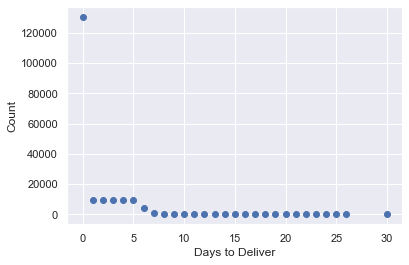

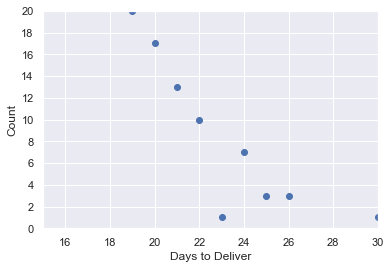

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

sns.set_theme(style="darkgrid")

plt.scatter(df_eda.days_to_deliver.value_counts().index,df_eda.days_to_deliver.value_counts())
plt.xlabel('Days to Deliver')
plt.ylabel('Count')
plt.show()

ax = plt.figure().gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.scatter(df_eda.days_to_deliver.value_counts().index,df_eda.days_to_deliver.value_counts())
plt.xlim(15,30)
plt.ylim(0,20)
plt.xlabel('Days to Deliver')
plt.ylabel('Count')
plt.show()



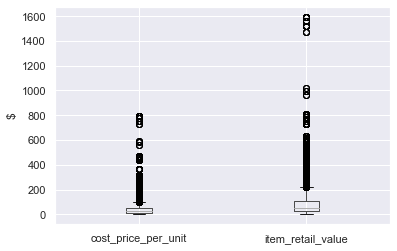

In [10]:
import matplotlib.pyplot as plt

df_eda.boxplot(column=['cost_price_per_unit','item_retail_value'])
plt.ylabel('$')
plt.show()

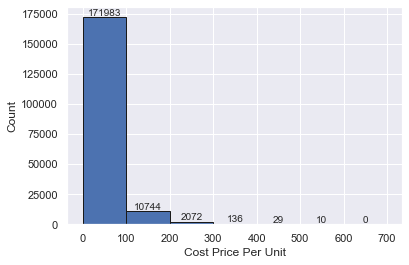

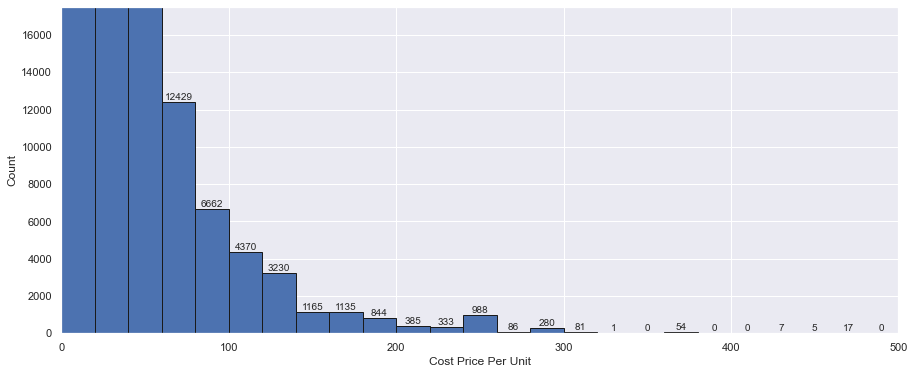

In [11]:
# Cost Per Unit
import numpy as np
import matplotlib.pyplot as plt


counts, edges, bars = plt.hist(df_eda.cost_price_per_unit, bins=np.arange(0, 800,100), edgecolor='k')
plt.bar_label(bars)
plt.xlabel('Cost Price Per Unit')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(15,6))
counts, edges, bars = plt.hist(df_eda.cost_price_per_unit, bins=np.arange(0, 800,20), edgecolor='k')
plt.bar_label(bars)
plt.xlim(0,500)
plt.ylim(0,17500)
plt.xlabel('Cost Price Per Unit')
plt.ylabel('Count')
plt.show()


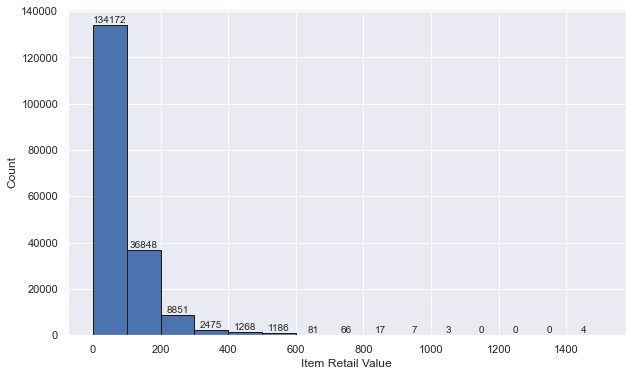

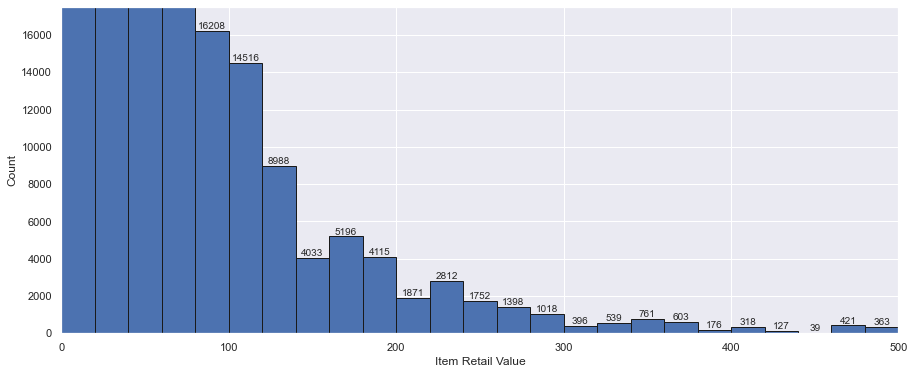

In [12]:
# Cost Per Unit
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))
counts, edges, bars = plt.hist(df_eda.item_retail_value, bins=np.arange(0, 1600,100), edgecolor='k')
plt.bar_label(bars)
plt.xlabel('Item Retail Value')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(15,6))
counts, edges, bars = plt.hist(df_eda.item_retail_value, bins=np.arange(0, 600,20), edgecolor='k')
plt.bar_label(bars)
plt.xlim(0,500)
plt.ylim(0,17500)
plt.xlabel('Item Retail Value')
plt.ylabel('Count')
plt.show()


### Product Supplier

In [13]:
df_eda_p = df_ps.copy()
df_ps

,product_id,product_line,product_category,product_group,product_name,supplier_country,supplier_name,supplier_id
0,210100100001,Children,Children Outdoors,"Outdoor things, Kids",Boy's and Girl's Ski Pants with Braces,NO,Scandinavian Clothing A/S,50
1,210100100002,Children,Children Outdoors,"Outdoor things, Kids",Children's Jacket,ES,Luna sastreria S.A.,4742
2,210100100003,Children,Children Outdoors,"Outdoor things, Kids",Children's Jacket Sidney,NO,Scandinavian Clothing A/S,50
3,210100100004,Children,Children Outdoors,"Outdoor things, Kids",Children's Rain Set,NO,Scandinavian Clothing A/S,50
4,210100100005,Children,Children Outdoors,"Outdoor things, Kids",Children's Rain Suit,NO,Scandinavian Clothing A/S,50
...,...,...,...,...,...,...,...,...
5499,240800200061,Sports,Winter Sports,Winter Sports,Top Equipe 00 White,US,Twain Inc,13198
5500,240800200062,Sports,Winter Sports,Winter Sports,Top Equipe 07 Green,US,Twain Inc,13198
5501,240800200063,Sports,Winter Sports,Winter Sports,Top Equipe 99 Black,US,Twain Inc,13198
5502,240800200064,Sports,Winter Sports,Winter Sports,Alpine Ski Bag 2-pair Black/Yellow,FR,Massif S.A.,13199


In [14]:
df_eda_p["product_line"].value_counts()

product_line
Sports             2354
Clothes & Shoes    2021
Children            772
Outdoors            357
Name: count, dtype: int64

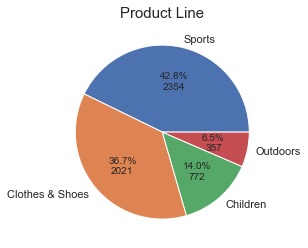

In [15]:
import matplotlib.pyplot as plt

total = df_eda_p['product_line'].value_counts().values.sum()

def fmt(x):
    return '{:.1f}%\n{:.0f}'.format(x, total*x/100)

plt.pie(df_eda_p['product_line'].value_counts().values, labels=df_eda_p['product_line'].value_counts().index, autopct=fmt)
plt.title('Product Line', fontsize = 15)
plt.show()

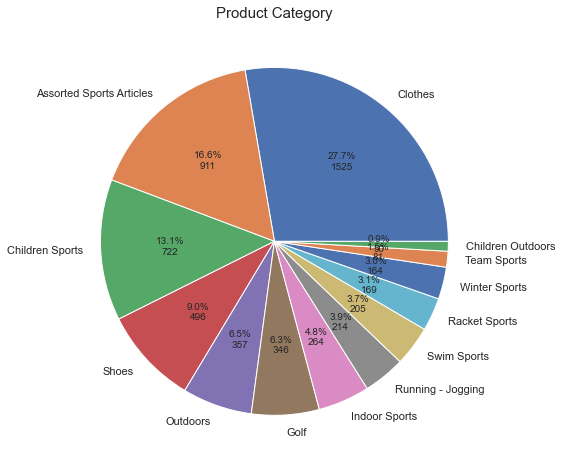

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

total = df_eda_p['product_category'].value_counts().values.sum()

def fmt(x):
    return '{:.1f}%\n{:.0f}'.format(x, total*x/100)

plt.pie(df_eda_p['product_category'].value_counts().values, labels=df_eda_p['product_category'].value_counts().index, autopct=fmt)
plt.title('Product Category', fontsize = 15)
plt.show()

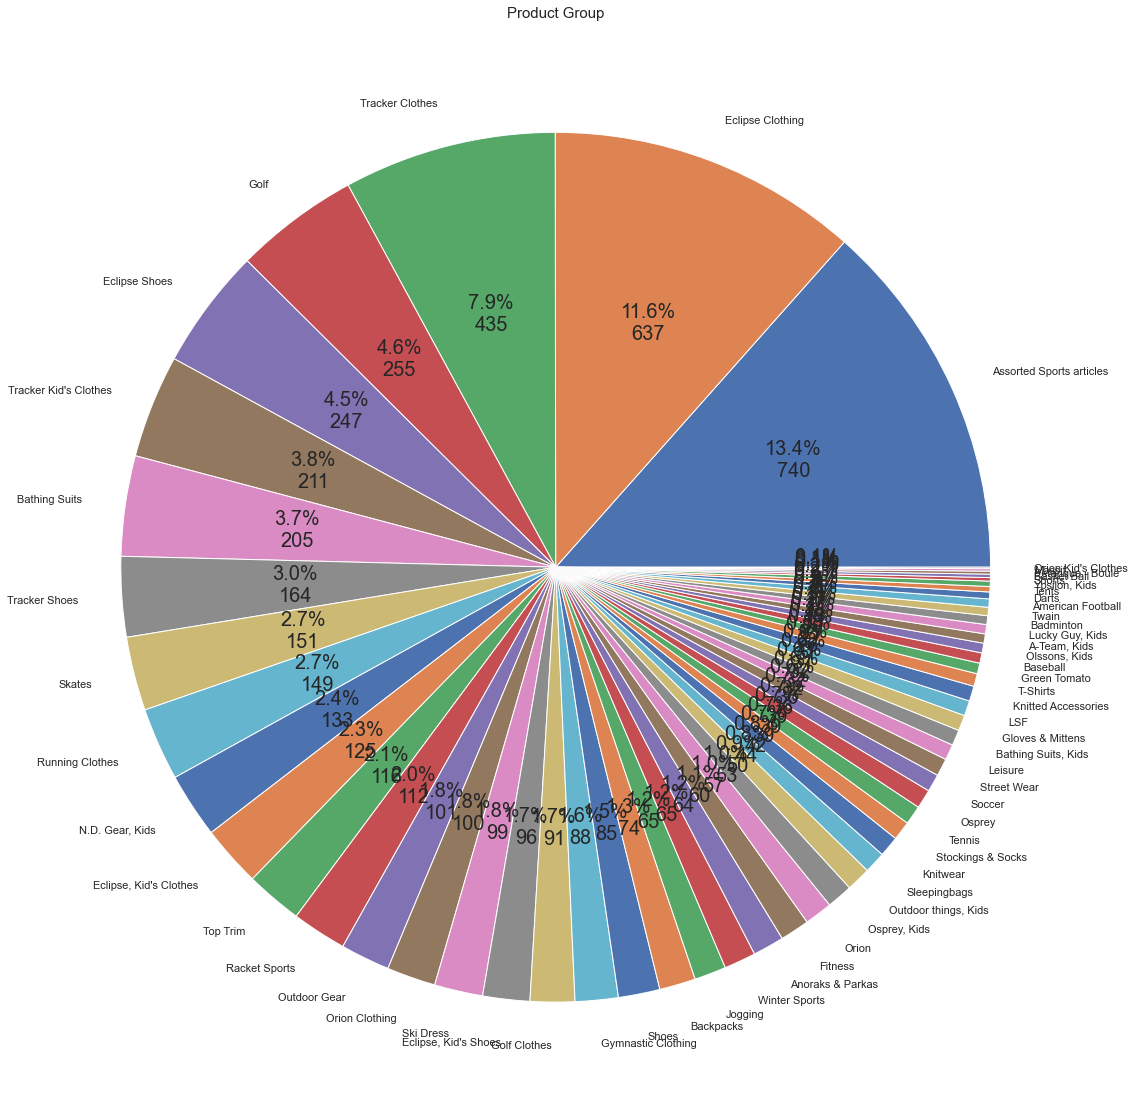

In [17]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 20

plt.figure(figsize=(20, 20))

total = df_eda_p['product_group'].value_counts().values.sum()

def fmt(x):
    return '{:.1f}%\n{:.0f}'.format(x, total*x/100)

plt.pie(df_eda_p['product_group'].value_counts().values, labels=df_eda_p['product_group'].value_counts().index, autopct=fmt)
plt.title('Product Group', fontsize = 15)
plt.savefig('product_group.png')
plt.show()

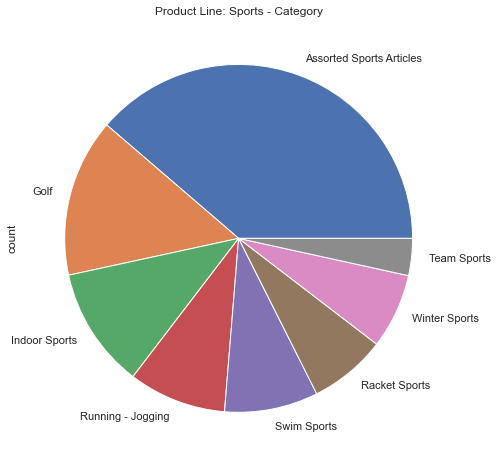

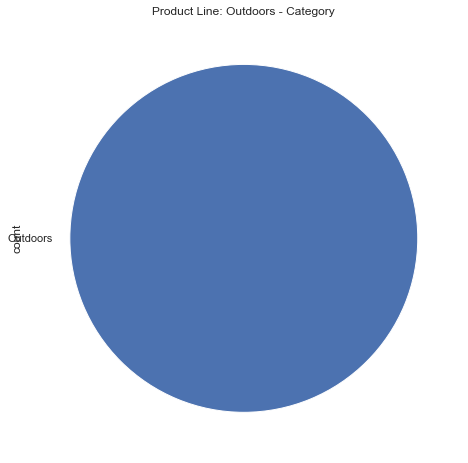

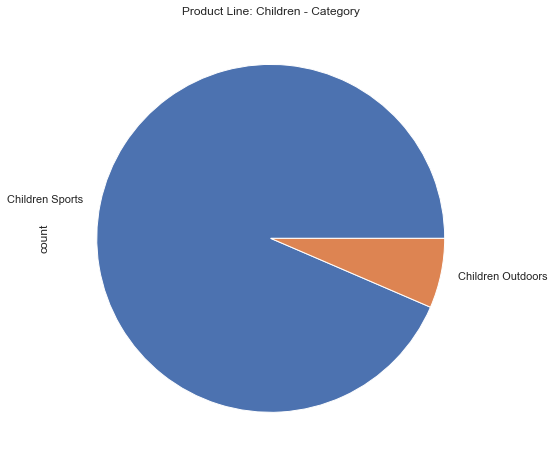

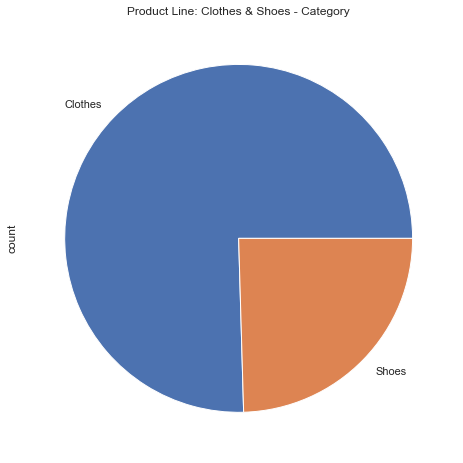

In [18]:
import matplotlib.pyplot as plt

# Visualiza the categorical columns using pie charts
# Change the font size of the labels
plt.rcParams['font.size'] = 8
mask = df_eda_p["product_line"]=="Sports"
df = df_eda_p.loc[mask,:]
# Pie chart for Product
plt.figure(figsize=(8, 8))
df["product_category"].value_counts().plot(kind="pie")
plt.title('Product Line: Sports - Category')
plt.show()


# Visualiza the categorical columns using pie charts
# Change the font size of the labels
plt.rcParams['font.size'] = 8
mask = df_eda_p["product_line"]=="Outdoors"
df = df_eda_p.loc[mask,:]
# Pie chart for Product
plt.figure(figsize=(8, 8))
df["product_category"].value_counts().plot(kind="pie")
plt.title('Product Line: Outdoors - Category')
plt.show()


# Visualiza the categorical columns using pie charts
# Change the font size of the labels
plt.rcParams['font.size'] = 8
mask = df_eda_p["product_line"]=="Children"
df = df_eda_p.loc[mask,:]
# Pie chart for Product
plt.figure(figsize=(8, 8))
df["product_category"].value_counts().plot(kind="pie")
plt.title('Product Line: Children - Category')
plt.show()


# Visualiza the categorical columns using pie charts
# Change the font size of the labels
plt.rcParams['font.size'] = 8
mask = df_eda_p["product_line"]=="Clothes & Shoes"
df = df_eda_p.loc[mask,:]
# Pie chart for Product
plt.figure(figsize=(8, 8))
df["product_category"].value_counts().plot(kind="pie")
plt.title('Product Line: Clothes & Shoes - Category')
plt.show()

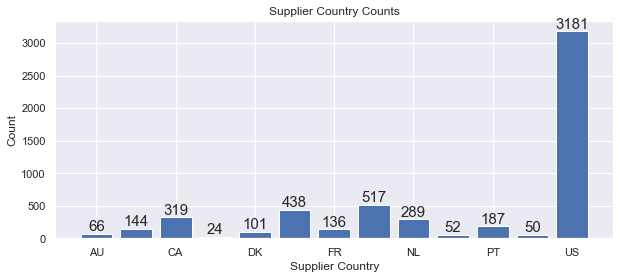

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 15})

dfp = df_eda_p.pivot_table(index='supplier_country', aggfunc='size')

# # plot
fig, ax = plt.subplots(1, 1, figsize=(10,4))
ax.bar(dfp.index, dfp.values)
# make the x axis integers
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
for container in ax.containers:
    ax.bar_label(container)
ax.set_title('Supplier Country Counts')
ax.set_xlabel('Supplier Country')
ax.set_ylabel('Count')
plt.show()


## Product Category

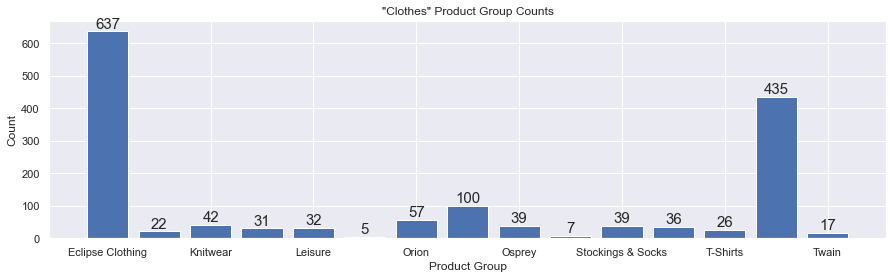

In [20]:
# df = df_eda_p.loc[df_eda_p["product_category"] == "Clothes",:].product_group

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 15})

dfp = df_eda_p.loc[df_eda_p["product_category"] == "Clothes",:].pivot_table(index='product_group', aggfunc='size')

# plot
fig, ax = plt.subplots(1, 1, figsize=(15,4))
ax.bar(dfp.index, dfp.values)
# make the x axis integers
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
for container in ax.containers:
    ax.bar_label(container)
ax.set_title('"Clothes" Product Group Counts')
ax.set_xlabel('Product Group')
ax.set_ylabel('Count')
plt.show()

### Time Series

##### Daily Change

In [24]:
df_merge_all = df_od.merge(df_ps, how='left', left_on='product_id', right_on='product_id')
df_merge = df_merge_all.copy()
df_merge.drop(columns=['customer_id','customer_status','order_id','product_id',
                       'days_to_deliver','supplier_country',
                      'supplier_id','supplier_name','product_line','product_group','product_name',
                      'date_year','date_month'], 
              axis=1, inplace=True)
df_merge

# Data Engineering
df_eng = df_merge.copy()


# Group Unit Cost into 5 groups
def group_cost(cost):
    if cost < 25:
        return 1
    elif cost >= 25 and cost < 50:
        return 2
    elif cost >= 50 and cost < 100:
        return 3
    elif cost >= 100 and cost < 200:
        return 4
    else:
        return 5

df_eng["cost_price_per_unit"] = df_eng["cost_price_per_unit"].apply(group_cost)


# Group Retail Value into 5 groups
def group_cost(cost):
    if cost < 50:
        return 1
    elif cost >= 50 and cost < 100:
        return 2
    elif cost >= 100 and cost < 200:
        return 3
    elif cost >= 200 and cost < 400:
        return 4
    else:
        return 5

df_eng["item_retail_value"] = df_eng["item_retail_value"].apply(group_cost)

# group by cost_price_per_unit, item_retail_value, date_year, date_month, and product_group
df_eng = df_eng.groupby(['cost_price_per_unit', 'item_retail_value', 'date_order_was_placed', 'product_category']).agg({'quantity_ordered': 'sum'}).reset_index()

df_eng

,cost_price_per_unit,item_retail_value,date_order_was_placed,product_category,quantity_ordered
0,1,1,2017-01-01,Children Sports,1
1,1,1,2017-01-01,Clothes,3
2,1,1,2017-01-01,Golf,1
3,1,1,2017-01-01,Outdoors,1
4,1,1,2017-01-01,Shoes,1
...,...,...,...,...,...
62539,5,5,2021-12-28,Indoor Sports,2
62540,5,5,2021-12-28,Outdoors,4
62541,5,5,2021-12-30,Assorted Sports Articles,1
62542,5,5,2021-12-30,Outdoors,2


Text(0.5, 1.0, 'Distribuitions of Orders by Product Category')

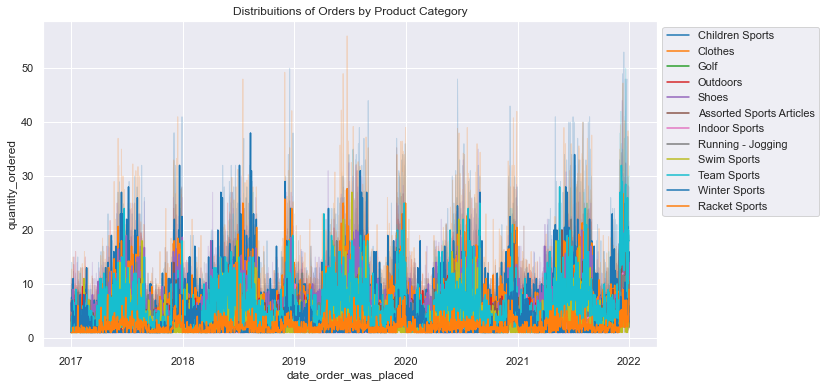

In [25]:
import matplotlib.pyplot as plt
_, ax = plt.subplots(figsize=(11,6))
sns.lineplot(data=df_eng,x='date_order_was_placed',
             y='quantity_ordered',
#              errorbar=None,
             hue='product_category',
             palette='tab10',ax=ax)
ax.legend(bbox_to_anchor=[1, 1])
ax.set_title('Distribuitions of Orders by Product Category')

#### Monthly Change

In [26]:
df_merge = df_od.merge(df_ps, how='left', left_on='product_id', right_on='product_id')
df_merge.drop(columns=['customer_id','customer_status','order_id','product_id',
                       'days_to_deliver','supplier_country',
                      'supplier_id','supplier_name','product_line','product_group','product_name',
                      'date_year','date_month'], 
              axis=1, inplace=True)
df_merge['date_order_was_placed'] = df_merge['date_order_was_placed'].dt.to_period('M')
df_merge.date_order_was_placed = df_merge.date_order_was_placed.astype('datetime64[M]')
# df_merge

# Data Engineering
df_eng = df_merge.copy()


# Group Unit Cost into 5 groups
def group_cost(cost):
    if cost < 25:
        return 1
    elif cost >= 25 and cost < 50:
        return 2
    elif cost >= 50 and cost < 100:
        return 3
    elif cost >= 100 and cost < 200:
        return 4
    else:
        return 5

df_eng["cost_price_per_unit"] = df_eng["cost_price_per_unit"].apply(group_cost)


# Group Retail Value into 5 groups
def group_cost(cost):
    if cost < 50:
        return 1
    elif cost >= 50 and cost < 100:
        return 2
    elif cost >= 100 and cost < 200:
        return 3
    elif cost >= 200 and cost < 400:
        return 4
    else:
        return 5

df_eng["item_retail_value"] = df_eng["item_retail_value"].apply(group_cost)

# group by cost_price_per_unit, item_retail_value, date_year, date_month, and product_group
df_eng = df_eng.groupby(['cost_price_per_unit', 'item_retail_value', 'date_order_was_placed', 'product_category']).agg({'quantity_ordered': 'sum'}).reset_index()

df_eng

,cost_price_per_unit,item_retail_value,date_order_was_placed,product_category,quantity_ordered
0,1,1,2017-01-01,Assorted Sports Articles,281
1,1,1,2017-01-01,Children Sports,222
2,1,1,2017-01-01,Clothes,288
3,1,1,2017-01-01,Golf,36
4,1,1,2017-01-01,Indoor Sports,58
...,...,...,...,...,...
5022,5,5,2021-12-01,Assorted Sports Articles,27
5023,5,5,2021-12-01,Golf,16
5024,5,5,2021-12-01,Indoor Sports,28
5025,5,5,2021-12-01,Outdoors,42


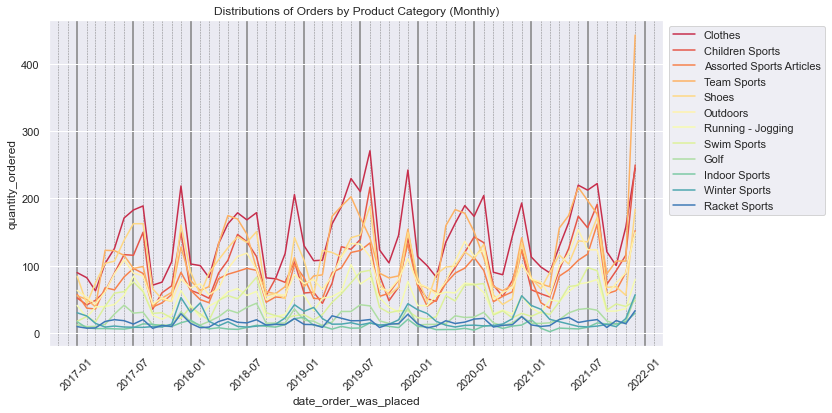

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.dates as mdates

# Set theme
sns.set_theme()

# Calculate the maximum 'quantity_ordered' for each 'product_category'
max_values = df_eng.groupby('product_category')['quantity_ordered'].max().reset_index()

# Sort by the maximum value
sorted_categories = max_values.sort_values(by='quantity_ordered', ascending=False)['product_category']

# Reorder the dataframe based on the sorted categories
df_eng['product_category'] = pd.Categorical(df_eng['product_category'], categories=sorted_categories, ordered=True)
df_eng_sorted = df_eng.sort_values('product_category')

# Create a Spectral palette
num_categories = df_eng['product_category'].nunique()
palette = sns.color_palette("Spectral", num_categories)

# Create plot with sorted categories
_, ax = plt.subplots(figsize=(11,6))
sns.lineplot(data=df_eng_sorted, x='date_order_was_placed',
             y='quantity_ordered',
             ci=None,
             hue='product_category',
             palette=palette, ax=ax)

# Set the major x-ticks to January and July
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))  # Ticks for January and July
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format as Year-Month

# Set the minor gridlines for every month
ax.xaxis.set_minor_locator(mdates.MonthLocator())  # Gridlines for every month

# Add gridlines for minor ticks (monthly)
ax.grid(True, which='minor', axis='x', linestyle='--', linewidth=0.5, color='gray')

# Customize the major gridlines for January and July (bold)
ax.grid(True, which='major', axis='x', linestyle='-', linewidth=1.5, color='gray')  # Bolder gridlines for January and July

# Rotate the x-ticks by 45 degrees
plt.xticks(rotation=45)

# Adjust legend
ax.legend(bbox_to_anchor=[1, 1])
ax.set_title('Distributions of Orders by Product Category (Monthly)')

plt.show()


## Data Engineering

In [28]:
# Merge
df_merge_all = df_od.merge(df_ps, how='left', left_on='product_id', right_on='product_id')
df_merge = df_merge_all.copy()
df_merge.drop(columns=['customer_id','customer_status','order_id','product_id',
                       'date_order_was_placed','days_to_deliver','supplier_country',
                      'supplier_id','supplier_name','product_line','product_group','product_name'], 
              axis=1, inplace=True)

# Data Engineering
df_eng = df_merge.copy()


# Group Unit Cost into 5 groups
def group_cost(cost):
    if cost < 25:
        return 1
    elif cost >= 25 and cost < 50:
        return 2
    elif cost >= 50 and cost < 100:
        return 3
    elif cost >= 100 and cost < 200:
        return 4
    else:
        return 5

df_eng["cost_price_per_unit"] = df_eng["cost_price_per_unit"].apply(group_cost)


# Group Retail Value into 5 groups
def group_cost(cost):
    if cost < 50:
        return 1
    elif cost >= 50 and cost < 100:
        return 2
    elif cost >= 100 and cost < 200:
        return 3
    elif cost >= 200 and cost < 400:
        return 4
    else:
        return 5

df_eng["item_retail_value"] = df_eng["item_retail_value"].apply(group_cost)

# group by cost_price_per_unit, item_retail_value, date_year, date_month, and product_group
df_eng = df_eng.groupby(['cost_price_per_unit', 'item_retail_value', 'date_year', 'date_month', 'product_category']).agg({'quantity_ordered': 'sum'}).reset_index()

df_eng

,cost_price_per_unit,item_retail_value,date_year,date_month,product_category,quantity_ordered
0,1,1,2017,1,Assorted Sports Articles,281
1,1,1,2017,1,Children Sports,222
2,1,1,2017,1,Clothes,288
3,1,1,2017,1,Golf,36
4,1,1,2017,1,Indoor Sports,58
...,...,...,...,...,...,...
5022,5,5,2021,12,Assorted Sports Articles,27
5023,5,5,2021,12,Golf,16
5024,5,5,2021,12,Indoor Sports,28
5025,5,5,2021,12,Outdoors,42


In [29]:
df_eng.product_category.unique()

array(['Assorted Sports Articles', 'Children Sports', 'Clothes', 'Golf',
       'Indoor Sports', 'Outdoors', 'Racket Sports', 'Running - Jogging',
       'Shoes', 'Swim Sports', 'Team Sports', 'Winter Sports'],
      dtype=object)

In [30]:
df_eng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5027 entries, 0 to 5026
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   cost_price_per_unit  5027 non-null   int64 
 1   item_retail_value    5027 non-null   int64 
 2   date_year            5027 non-null   int32 
 3   date_month           5027 non-null   int32 
 4   product_category     5027 non-null   object
 5   quantity_ordered     5027 non-null   int64 
dtypes: int32(2), int64(3), object(1)
memory usage: 196.5+ KB


In [31]:
df_eng.describe()

,cost_price_per_unit,item_retail_value,date_year,date_month,quantity_ordered
count,5027.000000,5027.000000,5027.000000,5027.000000,5027.000000
mean,2.419733,2.740004,2019.043167,6.540879,61.522976
std,1.211134,1.214810,1.406711,3.453642,114.120274
min,1.000000,1.000000,2017.000000,1.000000,1.000000
25%,1.000000,2.000000,2018.000000,4.000000,5.000000
50%,2.000000,3.000000,2019.000000,7.000000,16.000000
75%,3.000000,4.000000,2020.000000,10.000000,60.000000
max,5.000000,5.000000,2021.000000,12.000000,1132.000000


## Modeling

In [33]:
# Filter features
features = list(df_eng.columns)
target = 'quantity_ordered'
features.remove(target)
print(f'Features: {features}')
print(f'Target: {target}')

X = df_eng[features]
y = df_eng[target]

Features: ['cost_price_per_unit', 'item_retail_value', 'date_year', 'date_month', 'product_category']
Target: quantity_ordered


In [34]:
# Define loss function to calculate metrics
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from math import sqrt
import numpy as np

def new_accuracy(y_true, y_pred):
    accuracy_all = 1 - np.abs((y_true - y_pred) / y_true)
    accuracy = sum(accuracy_all)/len(accuracy_all)
    return accuracy

def loss(data, X, y_true, model):
    y_pred = model.predict(X)
    print(data, "MAE: {0:.2e}".format(mean_absolute_error(y_true, y_pred)))
    print(data, "MSE: {0:.2e}".format(mean_squared_error(y_true, y_pred)))
    print(data, "RMSE: {0:.2e}".format(sqrt(mean_squared_error(y_true, y_pred))))
    print(data, "R2 score : {0:.3f}".format(r2_score(y_true, y_pred)))
    print(data, "Accuracy : {0:.3f}%".format(new_accuracy(y_true, y_pred)))
    

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [35]:
# Preprocessing and model pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression


feat_num = list(X_train.select_dtypes(exclude='object').columns)
feat_cat = list(X_train.select_dtypes(include='object').columns)

# To rescale numerical and categorical data separately
colTransformer = ColumnTransformer([
    ('cat_cols', OneHotEncoder(handle_unknown='ignore'), feat_cat),
    ('num_cols', MinMaxScaler(), feat_num)
])



In [36]:
# Linear Regression
from sklearn.linear_model import LinearRegression
# Define the pipeline
steps_lr = [
    ("col_tf", colTransformer),
    ("lr", LinearRegression())
]
model_lr = Pipeline(steps_lr)
model_lr.fit(X_train, y_train)
# Model Performance
print("Linear Regression")
loss("Train", X_train, y_train, model_lr)
loss("Test", X_test, y_test, model_lr)
print("\n")


Linear Regression
Train MAE: 6.03e+01
Train MSE: 9.40e+03
Train RMSE: 9.70e+01
Train R2 score : 0.256
Train Accuracy : -7.200%
Test MAE: 6.34e+01
Test MSE: 1.09e+04
Test RMSE: 1.04e+02
Test R2 score : 0.255
Test Accuracy : -7.704%




In [37]:
from xgboost.sklearn import XGBRegressor
steps = [("preprocess", colTransformer),
         ('xgbr', XGBRegressor())]
model_xgb = Pipeline(steps)
model_xgb.fit(X_train, y_train)

# Model Performance
loss("Train", X_train, y_train, model_xgb)
loss("Test", X_test, y_test, model_xgb)

Train MAE: 7.33e+00
Train MSE: 1.44e+02
Train RMSE: 1.20e+01
Train R2 score : 0.989
Train Accuracy : 0.320%
Test MAE: 1.27e+01
Test MSE: 6.07e+02
Test RMSE: 2.46e+01
Test R2 score : 0.958
Test Accuracy : -0.114%


In [38]:
# CatBoostRegressor
from catboost import CatBoostRegressor
steps_cat = [("col_tf", colTransformer),
         ('catb', CatBoostRegressor(n_estimators=100, random_state=42, verbose=0))]
model_cat = Pipeline(steps_cat)
model_cat.fit(X_train, y_train)
# Model Performance
print("Cat Boost Regressor")
loss("Train", X_train, y_train, model_cat)
loss("Test", X_test, y_test, model_cat)
print("\n")

Cat Boost Regressor
Train MAE: 1.46e+01
Train MSE: 5.55e+02
Train RMSE: 2.36e+01
Train R2 score : 0.956
Train Accuracy : -0.562%
Test MAE: 1.79e+01
Test MSE: 1.02e+03
Test RMSE: 3.20e+01
Test R2 score : 0.930
Test Accuracy : -0.850%




In [39]:
# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
steps_gbr = [("col_tf", colTransformer),
         ('gbr', GradientBoostingRegressor())]
model_gbr = Pipeline(steps_gbr)
model_gbr.fit(X_train, y_train)
# Model Performance
print("Gradient Boosting Regressor")
loss("Train", X_train, y_train, model_gbr)
loss("Test", X_test, y_test, model_gbr)
print("\n")

Gradient Boosting Regressor
Train MAE: 3.56e+01
Train MSE: 3.85e+03
Train RMSE: 6.21e+01
Train R2 score : 0.695
Train Accuracy : -2.605%
Test MAE: 3.91e+01
Test MSE: 4.68e+03
Test RMSE: 6.84e+01
Test R2 score : 0.679
Test Accuracy : -2.818%




In [40]:
from lightgbm import LGBMRegressor

# Define the best parameters
best_params = {
    'n_estimators': 703,
    'learning_rate': 0.06814945127794421,
    'max_depth': 7,
    'reg_alpha': 0.07569481465417208,
    'reg_lambda': 2.1073371397761793,
    'num_leaves': 28,
    'subsample': 0.8680610615626715,
    'colsample_bytree': 0.893976646492343,
    'min_child_weight': 14,
    'min_split_gain': 0.7643791668215504,
    'subsample_freq': 2,
    'min_child_samples': 18,
    'device': 'cpu',  # Enable GPU support
    'gpu_platform_id': 0,  # Adjust if needed
    'gpu_device_id': 0,    # Adjust if needed
    'verbose': -1  # Suppress LightGBM output
}

# Train the model
steps_LGBM = [("preprocess", colTransformer),
         ("LGBM", LGBMRegressor(random_state=42))
         ]
model_LGBM = Pipeline(steps_LGBM)
model_LGBM.fit(X_train, y_train)


# Model Performance
loss("Train", X_train, y_train, model_LGBM)
loss("Test", X_test, y_test, model_LGBM)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 51
[LightGBM] [Info] Number of data points in the train set: 4021, number of used features: 16
[LightGBM] [Info] Start training from score 60.922905
Train MAE: 1.58e+01
Train MSE: 7.89e+02
Train RMSE: 2.81e+01
Train R2 score : 0.938
Train Accuracy : -0.573%
Test MAE: 1.92e+01
Test MSE: 1.34e+03
Test RMSE: 3.67e+01
Test R2 score : 0.908
Test Accuracy : -0.697%


In [41]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
steps_rf = [("col_tf", colTransformer),
         ("rf", RandomForestRegressor(n_estimators=100, random_state=42))
         ]
model_rf = Pipeline(steps_rf)
model_rf.fit(X_train, y_train)
# Model Performance
print("Random Forest")
loss("Train", X_train, y_train, model_rf)
loss("Test", X_test, y_test, model_rf)

Random Forest
Train MAE: 4.68e+00
Train MSE: 9.51e+01
Train RMSE: 9.75e+00
Train R2 score : 0.992
Train Accuracy : 0.651%
Test MAE: 1.32e+01
Test MSE: 9.00e+02
Test RMSE: 3.00e+01
Test R2 score : 0.938
Test Accuracy : 0.225%


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt
import pandas as pd

def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_metrics = get_metrics(y_train, train_pred)
    test_metrics = get_metrics(y_test, test_pred)

    row = {}

    for metric_name, value in train_metrics.items():
        row[("Train", metric_name)] = value

    for metric_name, value in test_metrics.items():
        row[("Test", metric_name)] = value

    return pd.DataFrame(row, index=[model_name])

In [55]:
results_table = pd.concat([
    evaluate_model("Linear Regression", model_lr, X_train, y_train, X_test, y_test),
    evaluate_model("Gradient Boosting", model_gbr, X_train, y_train, X_test, y_test),
    evaluate_model("LGBMRegressor", model_LGBM, X_train, y_train, X_test, y_test),
    evaluate_model("Cat Boost", model_cat, X_train, y_train, X_test, y_test),
    evaluate_model("XGB Regression", model_xgb, X_train, y_train, X_test, y_test),
    evaluate_model("Random Forest", model_rf, X_train, y_train, X_test, y_test)
])

results_table_formatted = results_table.copy()

for col in results_table_formatted.columns:
    if col[1] == "R2":
        results_table_formatted[col] = results_table_formatted[col].map("{:.3f}".format)
    else:
        results_table_formatted[col] = results_table_formatted[col].map("{:.2e}".format)

best_model_name = results_table[("Test", "RMSE")].idxmin()
print("Best model based on lowest test RMSE:", best_model_name)

results_table_formatted

Best model based on lowest test RMSE: XGB Regression


Train                                 Test            \
                        MAE       MSE      RMSE     R2       MAE       MSE   
Linear Regression  6.03e+01  9.40e+03  9.70e+01  0.256  6.34e+01  1.09e+04   
Gradient Boosting  3.56e+01  3.85e+03  6.21e+01  0.695  3.91e+01  4.68e+03   
LGBMRegressor      1.58e+01  7.89e+02  2.81e+01  0.938  1.92e+01  1.34e+03   
Cat Boost          1.46e+01  5.55e+02  2.36e+01  0.956  1.79e+01  1.02e+03   
XGB Regression     7.33e+00  1.44e+02  1.20e+01  0.989  1.27e+01  6.07e+02   
Random Forest      4.68e+00  9.51e+01  9.75e+00  0.992  1.32e+01  9.00e+02   

                                    
                       RMSE     R2  
Linear Regression  1.04e+02  0.255  
Gradient Boosting  6.84e+01  0.679  
LGBMRegressor      3.67e+01  0.908  
Cat Boost          3.20e+01  0.930  
XGB Regression     2.46e+01  0.958  
Random Forest      3.00e+01  0.938

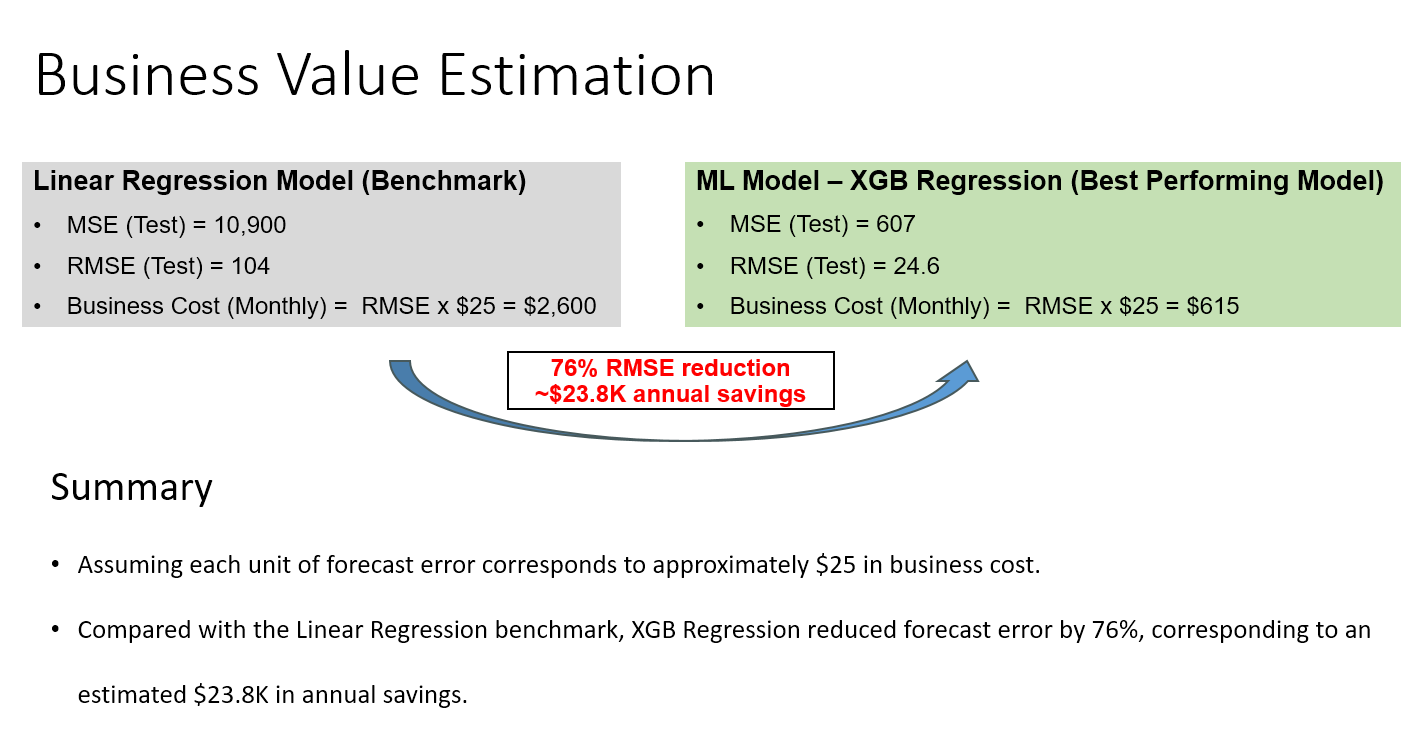

## Model Deployment


In [42]:
import joblib
# save the model to disk
joblib.dump(model_xgb, "model_xgb.sav")
joblib.dump(model_rf, "model_rf.sav")

['model_rf.sav']

### Generate example prediction for the year of 2025.

In [44]:
import pandas as pd
import numpy as np
import itertools
import joblib

# Load the CSV data
df_eng = pd.read_csv('data_eng.csv')

# Load the trained model (assumed to be in the XGBoost format, based on file extension)
model = joblib.load('model_xgb.sav')

# Create the possible combinations for cost_price, item_retail_value, date_month, and product_category
cost_price = list(range(1, 6)) 
item_retail_value = list(range(1, 6)) 
date_year = [2025]
date_month = list(range(1, 13))  # months from 1 to 12
product_category = df_eng['product_category'].unique()  

# Generate all possible combinations of the input features
combinations = list(itertools.product(cost_price, item_retail_value, date_year, date_month, product_category))

# Convert combinations into a dataframe
df_combinations = pd.DataFrame(combinations, columns=['cost_price_per_unit', 'item_retail_value', 'date_year', 'date_month', 'product_category'])

# Predict the quantity_ordered for each combination
df_combinations['quantity_ordered'] = model.predict(df_combinations)

# Show the dataframe with predictions
mask = df_combinations.quantity_ordered <  0
df_combinations.loc[mask,"quantity_ordered"] = 0
df_combinations.to_csv('order_forecast_2025.csv', index=False)
df_combinations

,cost_price_per_unit,item_retail_value,date_year,date_month,product_category,quantity_ordered
0,1,1,2025,1,Assorted Sports Articles,364.512695
1,1,1,2025,1,Children Sports,265.269592
2,1,1,2025,1,Clothes,385.011169
3,1,1,2025,1,Golf,64.316040
4,1,1,2025,1,Indoor Sports,59.075748
...,...,...,...,...,...,...
3595,5,5,2025,12,Running - Jogging,0.000000
3596,5,5,2025,12,Shoes,0.000000
3597,5,5,2025,12,Swim Sports,0.000000
3598,5,5,2025,12,Team Sports,0.000000
